is_returned                1.000000
discount_percentage        0.002670
order_id                   0.002068
session_duration_mins      0.002037
pages_viewed               0.001297
is_first_purchase          0.001002
days_to_deliver            0.000614
customer_lifetime_value    0.000235
quantity                  -0.000420
customer_age              -0.000679
num_reviews               -0.000858
clicks_to_purchase        -0.000995
customer_id               -0.001203
shipping_cost             -0.001265
product_base_price        -0.001294
product_id                -0.001383
total_amount              -0.001512
final_price               -0.001599
rating                    -0.004459
is_cancelled              -0.094577
Name: is_returned, dtype: float64


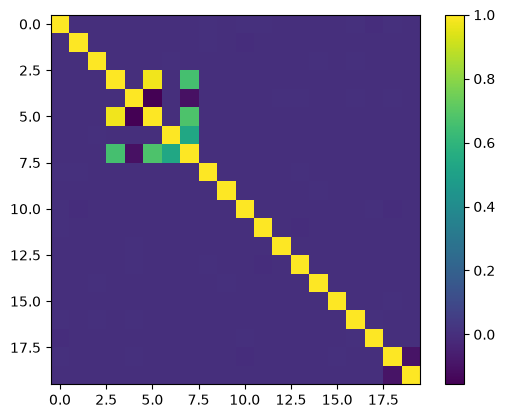

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\lenovo\Downloads\ecommerce_500k.csv")

corr = df.corr(numeric_only=True)

print(corr["is_returned"].sort_values(ascending=False))

plt.imshow(corr)
plt.colorbar()
plt.show()


In [4]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


df_model = pd.read_csv(r"C:\Users\lenovo\Downloads\ecommerce_500k.csv")

df_model = df_model.select_dtypes(exclude="string").fillna(0)

X = df_model.drop("is_returned", axis=1)
y = df_model["is_returned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

order_id                   0.077494
customer_id                0.077091
product_id                 0.076201
customer_lifetime_value    0.075303
total_amount               0.071698
product_base_price         0.070634
final_price                0.069608
session_duration_mins      0.067099
shipping_cost              0.062367
num_reviews                0.060463
dtype: float64
